## 10 001st Prime
By listing the first six prime numbers: `2, 3, 5, 7, 11 and 13`, we can see that the 6th prime is 13.  

What is the 10 001st prime number?

### Solution 1: Trial Division Method
This first solution utilizes two lines of reasoning in a trial division setup to fairly effectively find the prime at any given index.  

**Proposition One:** Since factors come in pairs, we only need to check a potential prime number up to the square root of the number.  

Consider you want to know if `101` is a prime number. If this number has a factor greater than `√101 ~ 10.04`, then its factor pair must be less than 10. Therefore, if we don't find a divisor by the square root, the number must be prime.  

---

**Proposition Two:** Any composite number is just the product of smaller primes. Therefore we can build a list of known primes and any larger potential prime number just needs to be checked for divisibility by the already known primes.  

Using the two above rationales and keeping track of the length of the known primes, we can terminate the code once this length reaches the inputted index for a prime.

In [1]:
import math

In [2]:
def prime_index_num(index_num: int = 10001) -> list[int] | None:
    """
    Generates a list of prime numbers up to a specified prime index using Trial Division.
    1. The function checks for divisibility of the square root of a potential prime.
    2. The function attempts division using previously discovered prime numbers.

    Args:
        index_num (int, optional) The total number of primes to find, i.e. the index prime you want. Defaults to 10001 by the Project Euler question.

    Returns:
        list[int] | None: A list containing the sequential primes up to the requested index. Returns None if the provided index is less than 1.
    """

    if index_num < 1:
        print(f"You entered {index_num} which is less than 1. Did you make a mistake?")
        return None

    prime_list = [2]
    number_to_check = 3

    # Apply Rationale 1+2 until the length of list of primes reaches the requested input prime index
    while len(prime_list) < index_num:
        is_prime = True
 
        for p in prime_list:
            if p * p > number_to_check:
                break

            if number_to_check % p == 0:
                is_prime = False
                break

        if is_prime:
            prime_list.append(number_to_check)

        number_to_check += 2
      
    return prime_list

### Solution

In [3]:
%%time
prime_index = 10001
prime_list = prime_index_num(prime_index)
print(f"Prime index [{prime_index}] is: {prime_list[-1]}")

Prime index [10001] is: 104743
CPU times: user 39.9 ms, sys: 863 μs, total: 40.8 ms
Wall time: 40.9 ms


### Solution 2: Sieve of Erastothenes
Solution 1 works fine for prime indices into the millions on most modern laptops and is certainly sufficient for just the 10001th prime.  
This second solution show an implementation of Sieve of Eratosthenes using Rosser's Theorem to set the upper limit of the Sieve.  

The **Sieve of Eratosthenes** is an ancient algorithm that iteratively marks composite numbers in a list of numbers up to some large number. The remaining unmarked numbers are the primes within that list.  

Since we do not know the upper limit that contains the requested prime index, we need some way to set an upper limit.  
Luckily we are saved by J. Barkley Rosser and his Theorem from 1939, which states that:

Let $p_n$ be the nth prime number. Then for $n >= 1$ it follows that $p_n > n \log n$  

**Note:** Rosser's Theorem was improved on by several authors, including Pierre Dusart in 2010. Implementing his upper boundary formula would reduce both the time and space complexity slightly. I challenge you to attempting this on your own and let me know how it compares!

In [4]:
def prime_index_num_fast(index_num: int) -> int:
    """
    Calculates the n-th prime number using the Sieve of Eratosthenes method.
    This function utilizes Rosser's Theorem to calculate an upper bound for the Sieve, that contains the n-th prime.

    Args:
        index_num (int): 1-based index of the prime number you wish to find (i.e., index_num=1 returns 2 and index_num=4 returns 7).

    Returns:
        int | None: The n-th prime number.
            Returns None if n < 1
            Returns -1 as a fallback if the bound fails. However this would indeed be worldview shattering.
    """
    
    
    # Rosser's formula is only guaranteed to produce limits strictly greater than the n-th prime when n >= 6.
    if index_num < 1:
        return None    
    if index_num == 1: return 2
    if index_num == 2: return 3
    if index_num == 3: return 5
    if index_num == 4: return 7
    if index_num == 5: return 11

    # Calculate a safe upper bound for our Sieve size (Rosser's Theorem)
    # This guarantees the sieve will be large enough to hold the n-th prime
    limit = int(index_num * (math.log(index_num) + math.log(math.log(index_num))))
    
    # Create the Sieve array, assuming all numbers are prime initially
    # This is just a list of Booleans
    sieve = [True] * (limit + 1)
    
    # 0 and 1 are mathematically not prime, manually setting these as False
    sieve[0] = False
    sieve[1] = False

    # The running prime index
    count = 0
    
    # Process the Sieve
    for p in range(2, limit + 1):
        
        if sieve[p]:
            count += 1
            
            # If we just found the n-th prime, return it immediately
            if count == index_num:
                return p
            
            # Cross out all multiples of p
            # We can safely start crossing out at p * p. This concept was explored in Solution 1. 
            # Any smaller multiple (like p * 2) was already crossed out by a smaller prime sieve
            for i in range(p * p, limit + 1, p):
                sieve[i] = False
                
    return -1 # Fallback, should never be reached if the bound is correct

### Differences in Time Complexity (Trial Division vs Sieve of Eratosthenes)

In [5]:
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [6]:
def benchmark_func(test_points: list):
    """
    Benchmarks and plots the execution time of the two prime-finding algorithms of this notebook.

    Args:
        test_points (list[int]): A list of integers representing the n-th prime indices to test the execution time for.

    Raises:
        ValueError: If `test_points` is not a list or is an empty list. More should be added, but I will assume no ill-intend or incapacity by the reader.
    """

    if not isinstance(test_points, list) or len(test_points) == 0:
        raise ValueError("You must pass a list containing at least one number")
    
    times_original = []
    times_sieve = []

    print(f"Running benchmark up to {test_points[-1]} (This may take about a minute...)")
    
    for n in test_points:
        
        # Trial Division Method
        start = time.perf_counter()
        prime_index_num(n)
        times_original.append(time.perf_counter() - start)
        
        # Sieve of Eratosthenes Method
        start = time.perf_counter()
        prime_index_num_fast(n)
        times_sieve.append(time.perf_counter() - start)

    plt.figure(figsize=(10, 6))
    
    plt.plot(test_points, times_original, marker='o', label='Trial Division', color='black')
    plt.plot(test_points, times_sieve, marker='^', label='Sieve Method', color='tomato')
    
    plt.title('Compute Times: Trial Division vs. Sieve of Eratosthenes', fontsize=14)
    plt.xlabel('n-th Prime', fontsize=12)
    plt.ylabel('Execution Time in Seconds', fontsize=12)
    plt.legend(fontsize=12)

    plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

    plt.tight_layout()
    plt.show()

In [7]:
nth_prime_list = [1000, 10000, 50000, 100000, 150000, 250000, 350000, 500000, 600000, 700000, 800000, 900000, 1000000]

Running benchmark up to 1000000 (This may take about a minute...)


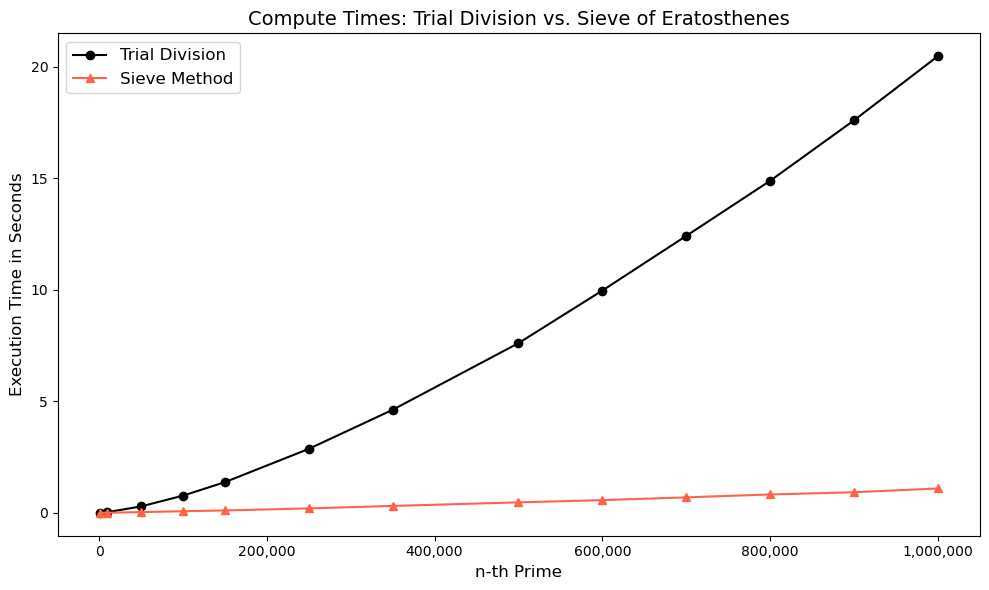

In [8]:
benchmark_func(nth_prime_list)

We see that the two time complexities meaningfully separate at around 100 thousand prime indices.  
Once you reach a million prime indices, the Trial Division is slower by ~25-30 fold.  
Mileage will vary depending on your computer. This was run on 32GB of DDR5 RAM and a i7-1165G7